In [1]:
!wget http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2shoes.tar.gz
!tar -xvf edges2shoes.tar.gz

Streaming output truncated to the last 5000 lines.
edges2shoes/train/46382_AB.jpg
edges2shoes/train/46383_AB.jpg
edges2shoes/train/46384_AB.jpg
edges2shoes/train/46385_AB.jpg
edges2shoes/train/46386_AB.jpg
edges2shoes/train/46387_AB.jpg
edges2shoes/train/46388_AB.jpg
edges2shoes/train/46389_AB.jpg
edges2shoes/train/4638_AB.jpg
edges2shoes/train/46390_AB.jpg
edges2shoes/train/46391_AB.jpg
edges2shoes/train/46392_AB.jpg
edges2shoes/train/449_AB.jpg
edges2shoes/train/44_AB.jpg
edges2shoes/train/45000_AB.jpg
edges2shoes/train/45001_AB.jpg
edges2shoes/train/45002_AB.jpg
edges2shoes/train/45003_AB.jpg
edges2shoes/train/45004_AB.jpg
edges2shoes/train/45005_AB.jpg
edges2shoes/train/45006_AB.jpg
edges2shoes/train/45007_AB.jpg
edges2shoes/train/45008_AB.jpg
edges2shoes/train/45009_AB.jpg
edges2shoes/train/4500_AB.jpg
edges2shoes/train/45010_AB.jpg
edges2shoes/train/45011_AB.jpg
edges2shoes/train/45012_AB.jpg
edges2shoes/train/45013_AB.jpg
edges2shoes/train/45687_AB.jpg
edges2shoes/train/45688_AB

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
class Edges2Shoes(torch.utils.data.Dataset):
    def __init__(self, root):
        self.root = root
        self.files = os.listdir(root)
        self.transform = transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root, self.files[idx])).convert("RGB")
        w, h = img.size

        edge = img.crop((0,0,w//2,h))
        real = img.crop((w//2,0,w,h))

        return self.transform(edge), self.transform(real)

dataset = Edges2Shoes("edges2shoes/train")
loader = DataLoader(dataset, batch_size=4, shuffle=True)

In [4]:
class DownBlock(nn.Module):
    def __init__(self, in_c, out_c, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class UpBlock(nn.Module):
    def __init__(self, in_c, out_c, dropout=False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = self.model(x)
        x = torch.cat((x, skip), 1)
        return x


class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1 = DownBlock(3, 64, normalize=False)
        self.d2 = DownBlock(64, 128)
        self.d3 = DownBlock(128, 256)
        self.d4 = DownBlock(256, 512)

        self.u1 = UpBlock(512, 256)
        self.u2 = UpBlock(512, 128)
        self.u3 = UpBlock(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)

        u1 = self.u1(d4, d3)
        u2 = self.u2(u1, d2)
        u3 = self.u3(u2, d1)

        return self.final(u3)

G = UNetGenerator().to(device)

In [5]:
class PatchDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, 4, 1, 1)  # Patch output
        )

    def forward(self, x, y):
        x = torch.cat((x,y), 1)
        return self.model(x)

D = PatchDiscriminator().to(device)

In [6]:
adv_loss = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()

optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

lambda_L1 = 100

In [8]:
epochs = 5

for epoch in range(epochs):
    for edges, real in loader:
        edges = edges.to(device)
        real = real.to(device)

        # Real and Fake labels
        real_label = torch.ones_like(D(edges, real))
        fake_label = torch.zeros_like(D(edges, real))

        # -----------------
        # Train Discriminator
        # -----------------
        fake = G(edges).detach()

        loss_real = adv_loss(D(edges, real), real_label)
        loss_fake = adv_loss(D(edges, fake), fake_label)
        loss_D = (loss_real + loss_fake) * 0.5

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # -----------------
        # Train Generator
        # -----------------
        fake = G(edges)
        loss_G_adv = adv_loss(D(edges, fake), real_label)
        loss_G_L1 = l1_loss(fake, real) * lambda_L1

        loss_G = loss_G_adv + loss_G_L1

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch {epoch+1} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Epoch 1 | D Loss: 0.6976 | G Loss: 17.2045
Epoch 2 | D Loss: 0.0097 | G Loss: 24.6145
Epoch 3 | D Loss: 1.4380 | G Loss: 16.5709
Epoch 4 | D Loss: 1.8195 | G Loss: 8.9976
Epoch 5 | D Loss: 0.1230 | G Loss: 15.3329


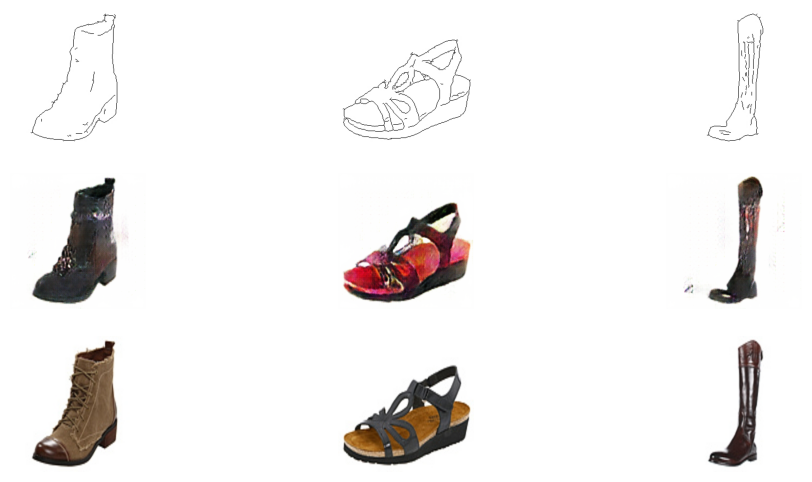

In [9]:
def denorm(x):
    return x * 0.5 + 0.5

G.eval()
edges, real = next(iter(loader))
edges = edges.to(device)

with torch.no_grad():
    fake = G(edges)

edges = denorm(edges.cpu())
real = denorm(real.cpu())
fake = denorm(fake.cpu())

plt.figure(figsize=(12,6))

for i in range(3):
    plt.subplot(3,3,i+1)
    plt.imshow(np.transpose(edges[i],(1,2,0)))
    plt.axis("off")

    plt.subplot(3,3,i+4)
    plt.imshow(np.transpose(fake[i],(1,2,0)))
    plt.axis("off")

    plt.subplot(3,3,i+7)
    plt.imshow(np.transpose(real[i],(1,2,0)))
    plt.axis("off")

plt.show()